# CKD Transmission Tutorial (load only): ArtTransPure with OpaCKD

Hajime Kawahara with Claude Code, September 24th (2025)

This tutorial demonstrates how to use the Correlated K-Distribution (CKD) method for atmospheric transmission calculations with ExoJAX, by loading exisiting saved data. 
We also run a simple HMC-NUTS using generated data.

In [1]:
# Import required packages
import numpy as np
import matplotlib.pyplot as plt
from jax import config

# ExoJAX imports
from exojax.test.emulate_mdb import mock_wavenumber_grid
from exojax.opacity import OpaCKD
from exojax.rt import ArtTransPure

# Enable 64-bit precision for accurate calculations
config.update("jax_enable_x64", True)

print("ExoJAX CKD Tutorial: Transmission Spectroscopy")
print("=============================================")

ExoJAX CKD Tutorial: Transmission Spectroscopy


## 1. Setup Atmospheric Model and Molecular Database

First, we'll set up our atmospheric model for transmission spectroscopy calculations.

In [2]:
# Setup wavenumber grid and molecular database
nu_grid, wav, res = mock_wavenumber_grid()
print(f"Wavenumber grid: {len(nu_grid)} points from {nu_grid[0]:.1f} to {nu_grid[-1]:.1f} cm⁻¹")
print(f"Spectral resolution: {res:.1f}")


# Setup atmospheric radiative transfer for transmission
art = ArtTransPure(
    pressure_top=1.0e-8, 
    pressure_btm=1.0e2, 
    nlayer=50,  # Fewer layers for transmission calculations
    integration="simpson"  # Simpson integration for better accuracy
)

print(f"Atmospheric layers: {art.nlayer}")
print(f"Pressure range: {art.pressure_top:.1e} - {art.pressure_btm:.1e} bar")
print(f"Integration method: {art.integration}")

xsmode =  modit
xsmode assumes ESLOG in wavenumber space: xsmode=modit
Your wavelength grid is in ***  ascending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
Wavenumber grid: 20000 points from 4329.0 to 4363.0 cm⁻¹
Spectral resolution: 2556525.8
integration:  simpson
Simpson integration, uses the chord optical depth at the lower boundary and midppoint of the layers.
Atmospheric layers: 50
Pressure range: 1.0e-08 - 1.0e+02 bar
Integration method: simpson


/home/kawahara/exojax/src/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/kawahara/exojax/src/exojax/rt/common.py:40: UserWarning: nu_grid is not given. specify nu_grid when using 'run' 
  warnings.warn(


## 2. Define Atmospheric and Planetary Parameters

We'll create atmospheric profiles and define planetary parameters for transmission calculations.

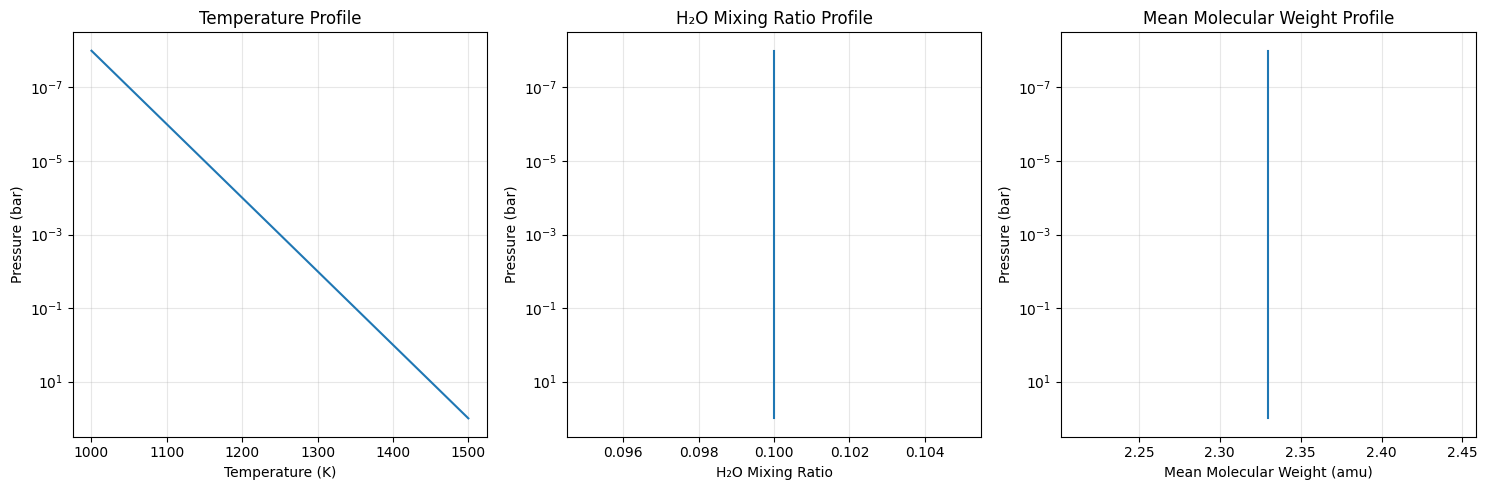

Temperature range: 1000 - 1500 K
H2O mixing ratio: 0.1 (constant)
Mean molecular weight: 2.33 amu (constant)
Planet radius: 1.0 R_Jupiter
Surface gravity: 2479 cm/s² (1.0 × Jupiter)


In [3]:
# Create atmospheric profiles
Tarr = np.linspace(1000.0, 1500.0, 50)  # Temperature profile
mmr_arr = np.full(50, 0.1)  # Constant H2O mixing ratio
mean_molecular_weight = np.full(50, 2.33)  # Mean molecular weight (H2-dominated)

# Planetary parameters (Jupiter-like)
radius_btm = 6.9e9  # Planet radius at bottom of atmosphere (cm)
gravity = 2478.57   # Surface gravity (cm/s²)

# Plot atmospheric profiles
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Temperature profile
ax1.semilogy(Tarr, art.pressure)
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Pressure (bar)')
ax1.set_title('Temperature Profile')
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()

# Mixing ratio profile
ax2.semilogy(mmr_arr, art.pressure)
ax2.set_xlabel('H₂O Mixing Ratio')
ax2.set_ylabel('Pressure (bar)')
ax2.set_title('H₂O Mixing Ratio Profile')
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()

# Mean molecular weight profile
ax3.semilogy(mean_molecular_weight, art.pressure)
ax3.set_xlabel('Mean Molecular Weight (amu)')
ax3.set_ylabel('Pressure (bar)')
ax3.set_title('Mean Molecular Weight Profile')
ax3.grid(True, alpha=0.3)
ax3.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Temperature range: {np.min(Tarr):.0f} - {np.max(Tarr):.0f} K")
print(f"H2O mixing ratio: {mmr_arr[0]:.1f} (constant)")
print(f"Mean molecular weight: {mean_molecular_weight[0]:.2f} amu (constant)")
print(f"Planet radius: {radius_btm/6.9e9:.1f} R_Jupiter")
print(f"Surface gravity: {gravity:.0f} cm/s² ({gravity/2478.57:.1f} × Jupiter)")

## 3. Setup CKD Opacity Calculator and Compute Transmission using the Saved Table Data

Now we'll directly load the CKD opacity table data and compute the CKD transmission spectrum.

In [4]:
opa_ckd = OpaCKD.from_saved_tables("ckd_h2o.npz") #one liner, no initialization needed
# Alternatively, load only the CKD object and then load tables
#ckd = OpaCKD.load_only()                       
#ckd.load_tables("ckd_h2o.npz")   
molmass = 18.02  # Molecular mass of H2O (g/mol)


print(f"CKD Opacity Calculator Setup:")
print(f"  Number of g-ordinates (Ng): {opa_ckd.Ng}")
print(f"  Band width: {opa_ckd.band_width}")
print(f"  Number of spectral bands: {len(opa_ckd.nu_bands)}")
print(f"  Spectral range: {opa_ckd.nu_bands[0]:.1f} - {opa_ckd.nu_bands[-1]:.1f} cm⁻¹")

# Pre-compute CKD tables on temperature-pressure grid
print("\nPre-computing CKD tables...")
T_grid = np.linspace(np.min(Tarr), np.max(Tarr), 10)
P_grid = np.logspace(np.log10(np.min(art.pressure)), np.log10(np.max(art.pressure)), 10)


# Get CKD cross-section tensor and compute CKD spectrum
print("Computing CKD transmission spectrum...")
xs_ckd = opa_ckd.xstensor_ckd(Tarr, art.pressure)
dtau_ckd = art.opacity_profile_xs_ckd(xs_ckd, mmr_arr, molmass, gravity)
transit_ckd = art.run_ckd(dtau_ckd, Tarr, mean_molecular_weight, radius_btm, gravity, opa_ckd.ckd_info.weights)

print(f"CKD spectrum computed!")
print(f"CKD transit range: [{np.min(transit_ckd):.6f}, {np.max(transit_ckd):.6f}]")

CKD Opacity Calculator Setup:
  Number of g-ordinates (Ng): 16
  Band width: 0.5
  Number of spectral bands: 68
  Spectral range: 4329.3 - 4362.8 cm⁻¹

Pre-computing CKD tables...
Computing CKD transmission spectrum...
CKD spectrum computed!
CKD transit range: [1.042467, 1.071651]


## 4. Generate Mock Data 

In [38]:
3#make mock data
from numpy.random import default_rng

rng = default_rng(seed=12)
sigma = 0.003
mock_data = transit_ckd + rng.normal(0, sigma, len(transit_ckd))


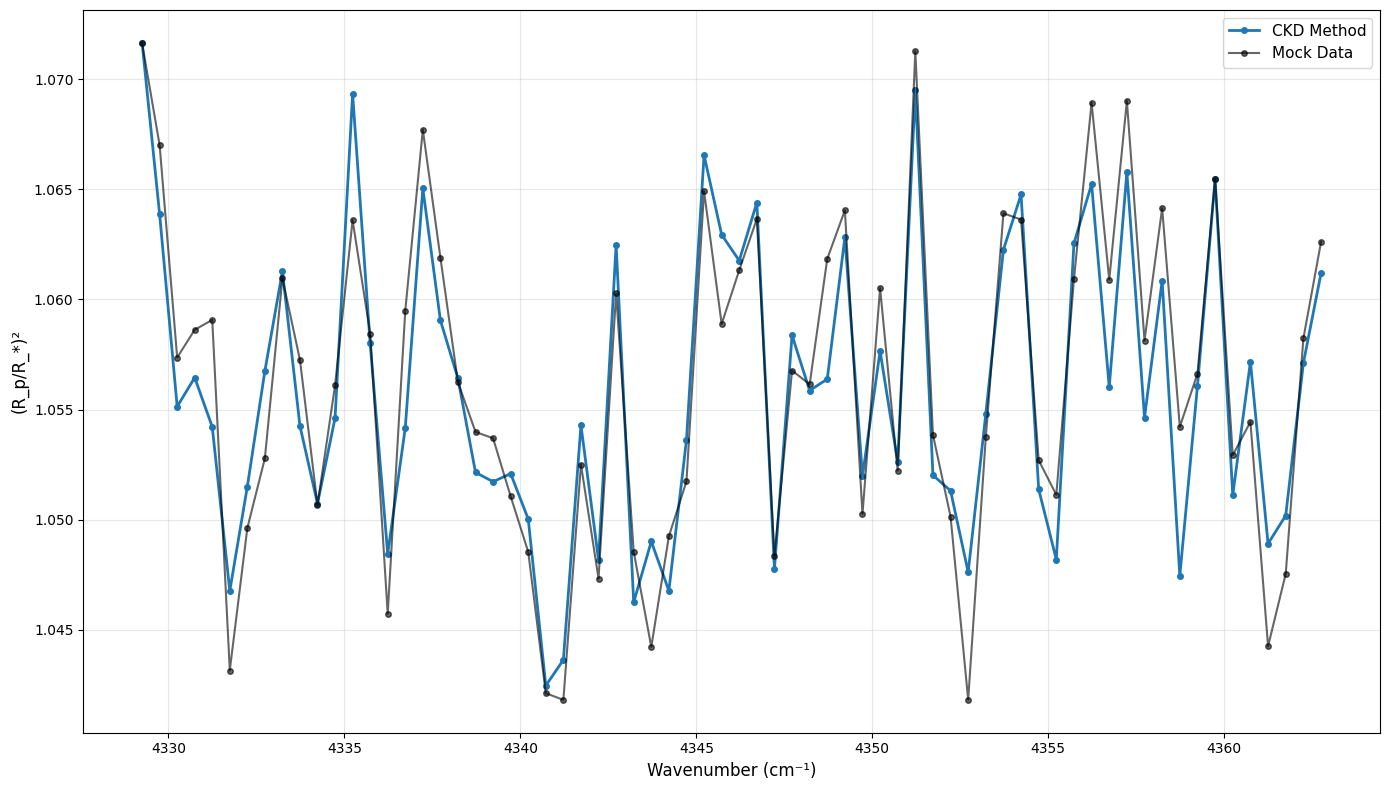

In [39]:
# Create comparison plot
plt.figure(figsize=(14, 8))
plt.plot(opa_ckd.nu_bands, transit_ckd, 
         'o-', label="CKD Method", 
         markersize=4, linewidth=2, color='C0')
plt.plot(opa_ckd.nu_bands, mock_data, 
         'o-', label="Mock Data", 
         markersize=4, color='black', alpha=0.6)
plt.xlabel('Wavenumber (cm⁻¹)', fontsize=12)
plt.ylabel('(R_p/R_*)²', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 5. Runs HMC-NUTS!

In [40]:
import jax.numpy as jnp

def fspec(mmr_const):
    mmr_arr = jnp.full(50, mmr_const)  # Constant H2O mixing ratio

    xs_ckd = opa_ckd.xstensor_ckd(Tarr, art.pressure)
    dtau_ckd = art.opacity_profile_xs_ckd(xs_ckd, mmr_arr, molmass, gravity)
    mu = art.run_ckd(dtau_ckd, Tarr, mean_molecular_weight, radius_btm, gravity, opa_ckd.ckd_info.weights)
    return mu


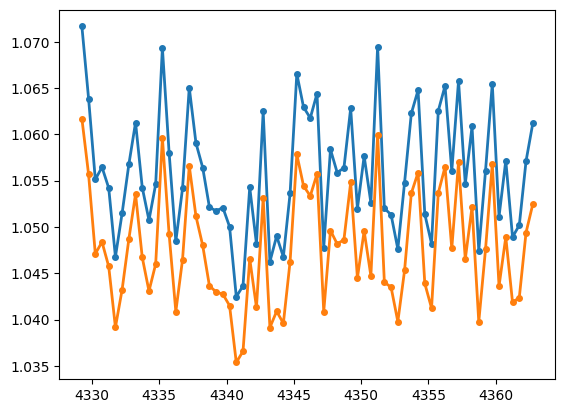

In [41]:
plt.plot(opa_ckd.nu_bands, fspec(0.1), 'o-', label="CKD Method (mmr=0.1)", markersize=4, linewidth=2, color='C0')
plt.plot(opa_ckd.nu_bands, fspec(0.01), 'o-', label="CKD Method (mmr=0.05)", markersize=4, linewidth=2, color='C1')


In [42]:
from numpyro.infer import MCMC, NUTS
import numpyro.distributions as dist
import numpyro
from jax import random

In [43]:
def model_prob(spectrum):

    #atmospheric/spectral model parameters priors
    mmr = numpyro.sample('MMR', dist.Uniform(0.0, 0.3))
    mu = fspec(mmr)

    #noise model parameters priors
    sigmain = numpyro.sample('sigmain', dist.Exponential(1.e0)) 

    numpyro.sample('spectrum', dist.Normal(mu, sigmain), obs=spectrum)

In [44]:
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
num_warmup, num_samples = 500, 1000
#kernel = NUTS(model_prob, forward_mode_differentiation=True)
kernel = NUTS(model_prob, forward_mode_differentiation=False)

In [45]:
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
mcmc.run(rng_key_, spectrum=mock_data)
mcmc.print_summary()

sample: 100%|██████████| 1500/1500 [00:10<00:00, 139.48it/s, 3 steps of size 8.29e-01. acc. prob=0.92] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       MMR      0.11      0.01      0.11      0.09      0.13    508.97      1.00
   sigmain      0.00      0.00      0.00      0.00      0.00   1082.87      1.00

Number of divergences: 0


In [46]:
from numpyro.diagnostics import hpdi
from numpyro.infer import Predictive
import jax.numpy as jnp

# SAMPLING
posterior_sample = mcmc.get_samples()
pred = Predictive(model_prob, posterior_sample, return_sites=['spectrum'])
predictions = pred(rng_key_, spectrum=None)
median_mu1 = jnp.median(predictions['spectrum'], axis=0)
hpdi_mu1 = hpdi(predictions['spectrum'], 0.9)

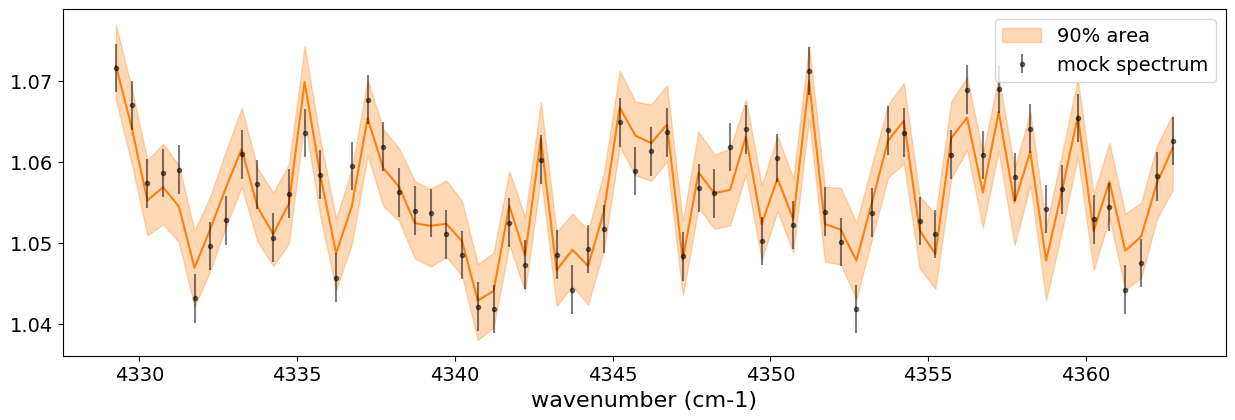

In [47]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 4.5))
ax.plot(opa_ckd.nu_bands, median_mu1, color='C1')
ax.fill_between(opa_ckd.nu_bands,
                hpdi_mu1[0],
                hpdi_mu1[1],
                alpha=0.3,
                interpolate=True,
                color='C1',
                label='90% area')
ax.errorbar(opa_ckd.nu_bands, mock_data, sigma, fmt=".", label="mock spectrum", color="black",alpha=0.5)
plt.xlabel('wavenumber (cm-1)', fontsize=16)
plt.legend(fontsize=14)
plt.tick_params(labelsize=14)
plt.show()

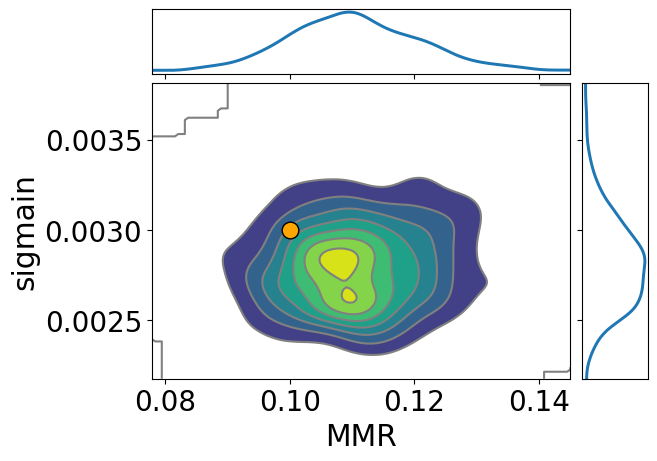

In [48]:
import arviz

pararr = ["MMR", "sigmain"]
arviz.plot_pair(
    arviz.from_numpyro(mcmc),
    kind="kde",
    divergences=False,
    marginals=True,
    reference_values={
        "MMR": 0.1,
        "sigmain": 0.003,
    },
    reference_values_kwargs={
        "marker": "o",
        "markersize": 12,
        "linestyle": "None",
        "color": "orange",
        },
    textsize=20,
)
plt.show()